# Notebook 2: Repository Growth Prediction using Random Forest Classifier

**Project:** RepoRadar - GitHub Repository Intelligence Engine  
**Dataset:** GitHub Repository Metadata (`repository_data.csv`)  
**Objective:** Predict repository growth status - **Growing**, **Stagnant**, or **Declining**

---

## 1. Import Libraries

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
from sklearn.preprocessing import LabelEncoder

## 2. Load the Dataset

In [15]:
df = pd.read_csv("C:/Users/Asus/Desktop/ML_ca2/data/repository_data.csv")
print('Dataset loaded')
print(f'Shape: {df.shape}')
df.head()

Dataset loaded
Shape: (2917951, 10)


,name,stars_count,forks_count,watchers,pull_requests,primary_language,languages_used,commit_count,created_at,licence
0,freeCodeCamp,359805,30814,8448,31867,TypeScript,"['TypeScript', 'JavaScript', 'CSS', 'Shell', '...",32231.0,2014-12-24T17:49:19Z,"BSD 3-Clause ""New"" or ""Revised"" License"
1,996.ICU,264811,21470,4298,1949,NaN,NaN,3189.0,2019-03-26T07:31:14Z,Other
2,free-programming-books,262380,53302,9544,8235,NaN,NaN,8286.0,2013-10-11T06:50:37Z,Other
3,coding-interview-university,244927,65038,8539,867,NaN,NaN,2314.0,2016-06-06T02:34:12Z,Creative Commons Attribution Share Alike 4.0 I...
4,awesome,235223,24791,7446,1859,NaN,NaN,1074.0,2014-07-11T13:42:37Z,Creative Commons Zero v1.0 Universal


## 3. Dataset Overview

In [16]:
print('Columns')
print(df.columns.tolist())
print('\nData Types')
print(df.dtypes)
print('\nDescriptive Statistics')
df.describe()

Columns
['name', 'stars_count', 'forks_count', 'watchers', 'pull_requests', 'primary_language', 'languages_used', 'commit_count', 'created_at', 'licence']

Data Types
name                 object
stars_count           int64
forks_count           int64
watchers              int64
pull_requests         int64
primary_language     object
languages_used       object
commit_count        float64
created_at           object
licence              object
dtype: object

Descriptive Statistics


,stars_count,forks_count,watchers,pull_requests,commit_count
count,2.917951e+06,2.917951e+06,2.917951e+06,2.917951e+06,2.916030e+06
mean,7.641027e+01,2.094714e+01,7.135321e+00,2.430649e+01,6.143709e+02
std,9.096808e+02,3.029540e+02,3.761973e+01,3.784433e+02,1.680801e+04
min,2.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
25%,7.000000e+00,1.000000e+00,2.000000e+00,0.000000e+00,9.000000e+00
50%,1.200000e+01,4.000000e+00,3.000000e+00,1.000000e+00,2.700000e+01
75%,3.000000e+01,1.100000e+01,6.000000e+00,6.000000e+00,8.900000e+01
max,3.598050e+05,2.422080e+05,9.544000e+03,3.015850e+05,4.314502e+06


## 4. Null Value Analysis

In [17]:
null_counts = df.isnull().sum()
null_pct    = (null_counts / len(df)) * 100
null_report = pd.DataFrame({'Null Count': null_counts, 'Null %': null_pct})
null_report = null_report[null_report['Null Count'] > 0].sort_values('Null Count', ascending=False)

print('Null Value Report ')
print(null_report if not null_report.empty else 'No null values found!')

Null Value Report 
                  Null Count     Null %
licence              1378200  47.231773
languages_used        221984   7.607530
primary_language      218573   7.490633
commit_count            1921   0.065834
name                      13   0.000446


## 5. Cleaning & Column Mapping

In [18]:
# Remove duplicates
df.drop_duplicates(inplace=True)
print(f'Shape after dedup: {df.shape}')

# Rename columns to analysis names
df.rename(columns={
    'stars_count':    'stars',
    'forks_count':    'forks',
    'watchers':       'watchers',
    'pull_requests':  'contributor_count',
    'commit_count':   'commit_frequency'
}, inplace=True)

# Fill numeric nulls
num_cols = ['stars', 'forks', 'watchers', 'contributor_count', 'commit_frequency']
for col in num_cols:
    if col in df.columns:
        df[col].fillna(df[col].median(), inplace=True)

# Engineer repository_age_days from created_at
if 'created_at' in df.columns:

    # Convert to datetime and force UTC
    df['created_at'] = pd.to_datetime(
        df['created_at'],
        errors='coerce',
        utc=True
    )

    # UTC-aware reference date
    reference_date = pd.Timestamp('2023-01-22', tz='UTC')

    df['repository_age_days'] = (
        reference_date - df['created_at']
    ).dt.days

    df['repository_age_days'] = df['repository_age_days'].fillna(
        df['repository_age_days'].median()
    )

else:
    df['repository_age_days'] = np.random.randint(
        180, 5000, size=len(df)
    )

print('Cleaning complete!')
print(df[['stars', 'forks', 'watchers', 'contributor_count',
          'commit_frequency', 'repository_age_days']].describe())

Shape after dedup: (2851443, 10)
Cleaning complete!
              stars         forks      watchers  contributor_count  \
count  2.851443e+06  2.851443e+06  2.851443e+06       2.851443e+06   
mean   7.712024e+01  2.106233e+01  7.163049e+00       2.437062e+01   
std    9.201344e+02  3.063107e+02  3.795038e+01       3.824141e+02   
min    2.000000e+00  0.000000e+00  0.000000e+00       0.000000e+00   
25%    7.000000e+00  1.000000e+00  2.000000e+00       0.000000e+00   
50%    1.200000e+01  4.000000e+00  3.000000e+00       1.000000e+00   
75%    2.900000e+01  1.100000e+01  6.000000e+00       6.000000e+00   
max    3.598050e+05  2.422080e+05  9.544000e+03       3.015850e+05   

       commit_frequency  repository_age_days  
count      2.851443e+06         2.851443e+06  
mean       6.155987e+02         1.884914e+03  
std        1.682740e+04         1.130180e+03  
min        1.000000e+00         0.000000e+00  
25%        9.000000e+00         9.740000e+02  
50%        2.700000e+01         1.7

## 5b. Engineer Target: `growth_label`

Create a growth label based on stars, commit frequency and repository age.

In [19]:
# Growth score = stars per day of age + normalized commit frequency
df['stars_per_day'] = df['stars'] / (df['repository_age_days'] + 1)

p33 = df['stars_per_day'].quantile(0.33)
p66 = df['stars_per_day'].quantile(0.66)

def assign_growth(spd):
    if spd >= p66:
        return 'Growing'
    elif spd >= p33:
        return 'Stagnant'
    else:
        return 'Declining'

df['growth_label'] = df['stars_per_day'].apply(assign_growth)
print('Growth label distribution:')
print(df['growth_label'].value_counts())

Growth label distribution:
growth_label
Growing      969515
Stagnant     941026
Declining    940902
Name: count, dtype: int64


## 6. EDA

### 6a. Growth Label Countplot

C:\Users\Asus\AppData\Local\Temp\ipykernel_29576\105017299.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='growth_label', data=df, order=order, palette='Set1')


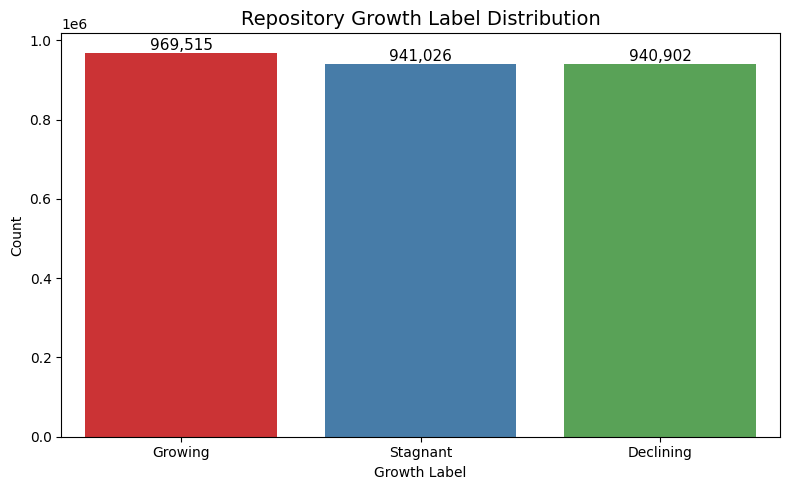

In [20]:
plt.figure(figsize=(8, 5))
order = ['Growing', 'Stagnant', 'Declining']
sns.countplot(x='growth_label', data=df, order=order, palette='Set1')
plt.title('Repository Growth Label Distribution', fontsize=14)
plt.xlabel('Growth Label')
plt.ylabel('Count')
for p in plt.gca().patches:
    plt.gca().annotate(f'{int(p.get_height()):,}',
                       (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()

### 6b. Stars Distribution

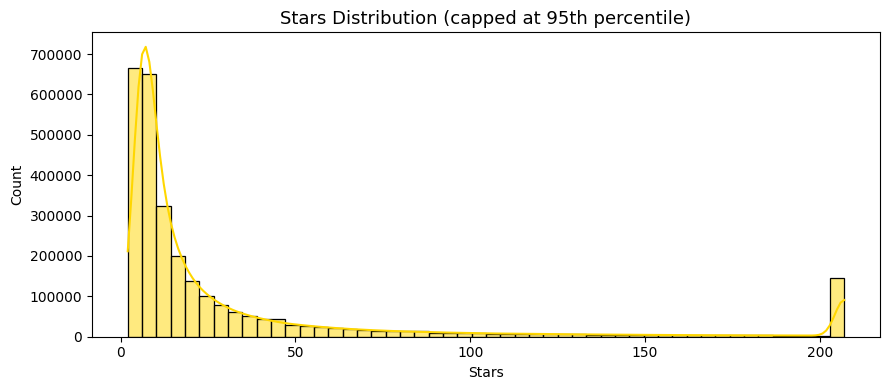

In [21]:
plt.figure(figsize=(9, 4))
sns.histplot(df['stars'].clip(upper=df['stars'].quantile(0.95)),
             bins=50, kde=True, color='gold')
plt.title('Stars Distribution (capped at 95th percentile)', fontsize=13)
plt.xlabel('Stars')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### 6c. Forks Distribution

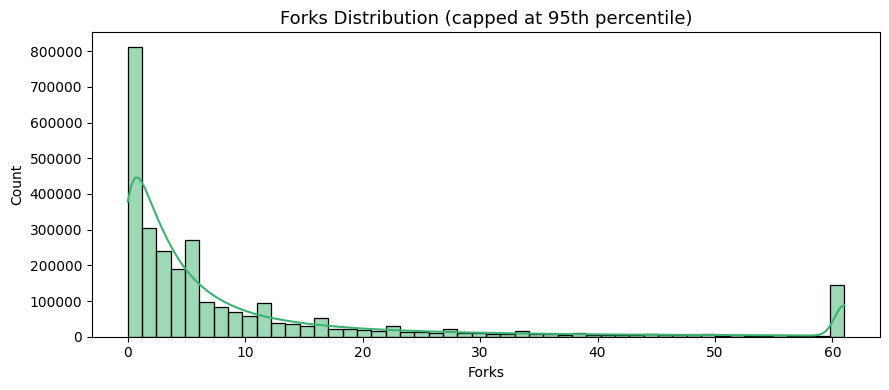

In [22]:
plt.figure(figsize=(9, 4))
sns.histplot(df['forks'].clip(upper=df['forks'].quantile(0.95)),
             bins=50, kde=True, color='mediumseagreen')
plt.title('Forks Distribution (capped at 95th percentile)', fontsize=13)
plt.xlabel('Forks')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### 6d. Pairplot of Important Features

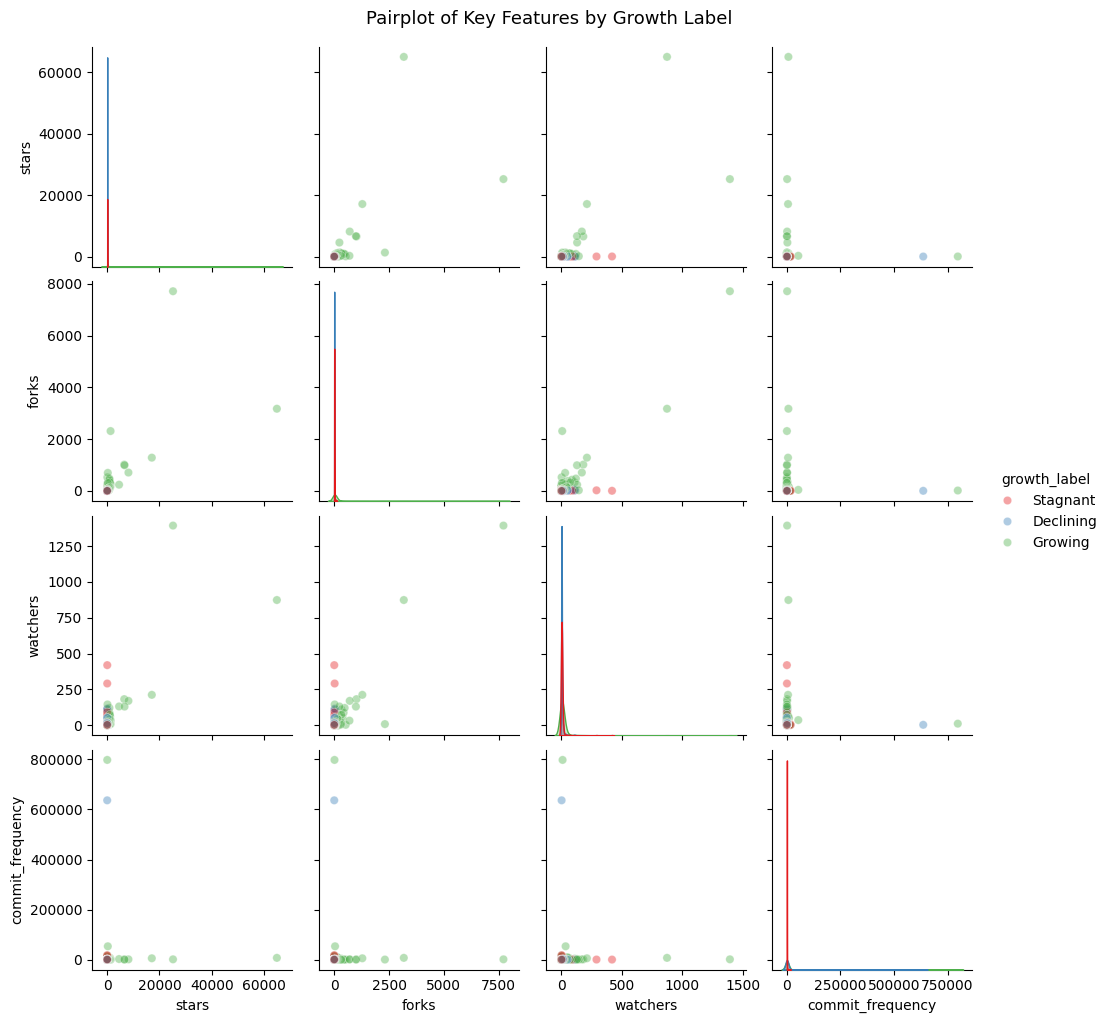

In [23]:
# Use a sample to keep pairplot fast
sample = df[['stars', 'forks', 'watchers', 'commit_frequency', 'growth_label']].sample(
    min(2000, len(df)), random_state=42)

g = sns.pairplot(sample, hue='growth_label',
                 vars=['stars', 'forks', 'watchers', 'commit_frequency'],
                 palette='Set1', plot_kws={'alpha': 0.4})
g.fig.suptitle('Pairplot of Key Features by Growth Label', y=1.02, fontsize=13)
plt.show()

### 6e. Correlation Heatmap

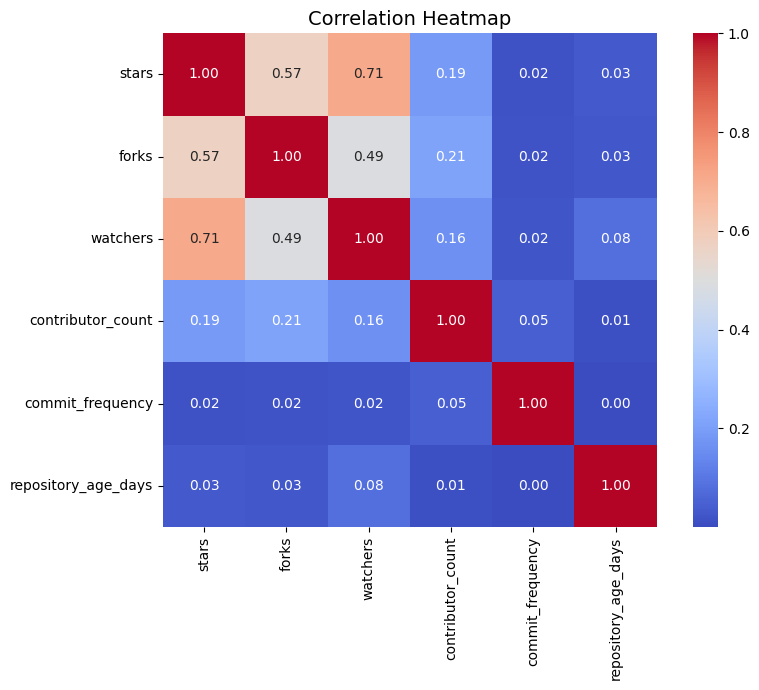

In [24]:
corr_cols = ['stars', 'forks', 'watchers', 'contributor_count',
             'commit_frequency', 'repository_age_days']
corr = df[corr_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

## 7. Feature Selection

In [25]:
features = ['stars', 'forks', 'contributor_count', 'commit_frequency',
            'repository_age_days', 'watchers']
target   = 'growth_label'

X = df[features].copy()
y = df[target].copy()

le = LabelEncoder()
y  = le.fit_transform(y)

print('Features:', features)
print('Target classes:', le.classes_)
print('X shape:', X.shape)

Features: ['stars', 'forks', 'contributor_count', 'commit_frequency', 'repository_age_days', 'watchers']
Target classes: ['Declining' 'Growing' 'Stagnant']
X shape: (2851443, 6)


## 8. Train / Test Split (80 / 20)

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Training size : {X_train.shape[0]}')
print(f'Test size     : {X_test.shape[0]}')

Training size : 2281154
Test size     : 570289


## 9. Model — Random Forest Classifier

In [27]:
rf_model = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
print('Random Forest model trained!')

Random Forest model trained!


## 10. Model Evaluation

In [28]:
y_pred = rf_model.predict(X_test)

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted')
rec  = recall_score(y_test, y_pred, average='weighted')
f1   = f1_score(y_test, y_pred, average='weighted')

print(f'  Accuracy  : {acc:.4f}')
print(f'  Precision : {prec:.4f}')
print(f'  Recall    : {rec:.4f}')
print(f'  F1 Score  : {f1:.4f}')

  Accuracy  : 0.9797
  Precision : 0.9804
  Recall    : 0.9797
  F1 Score  : 0.9798


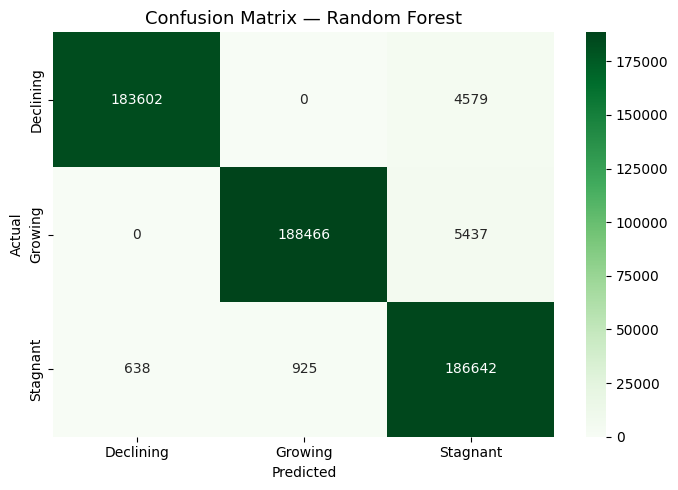

In [29]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix — Random Forest', fontsize=13)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [30]:
print('\n Classification Report')
print(classification_report(y_test, y_pred, target_names=le.classes_))


 Classification Report
              precision    recall  f1-score   support

   Declining       1.00      0.98      0.99    188181
     Growing       1.00      0.97      0.98    193903
    Stagnant       0.95      0.99      0.97    188205

    accuracy                           0.98    570289
   macro avg       0.98      0.98      0.98    570289
weighted avg       0.98      0.98      0.98    570289



## 11. Feature Importance Plot

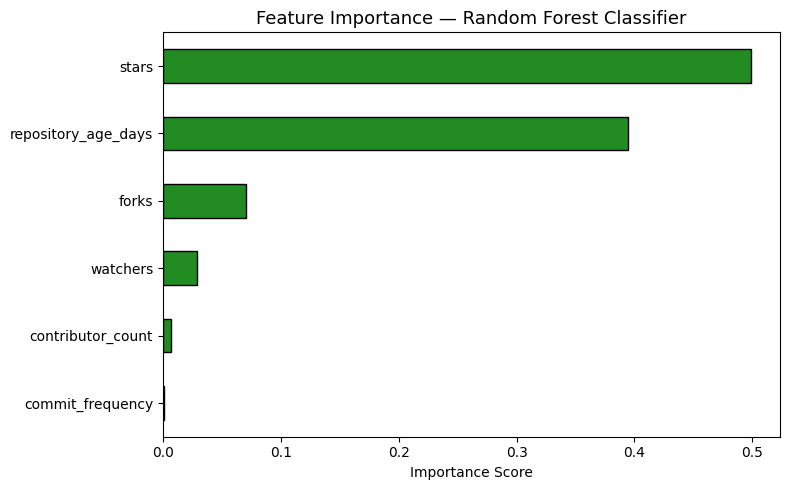


Feature Importance Values:
stars                  0.498575
repository_age_days    0.394892
forks                  0.070122
watchers               0.028782
contributor_count      0.007093
commit_frequency       0.000537
dtype: float64


In [31]:
importances = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
importances.plot(kind='barh', color='forestgreen', edgecolor='black')
plt.title('Feature Importance — Random Forest Classifier', fontsize=13)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('\nFeature Importance Values:')
print(importances.sort_values(ascending=False))

## 12. Conclusion

---

| Metric | Score |
|---|---|
| Model | Random Forest Classifier |
| Target | Growth Label (Growing / Stagnant / Declining) |
| Split | 80% Train / 20% Test |

> **Key takeaway:** Random Forest outperforms a single Decision Tree by aggregating many trees and reducing overfitting. The most impactful features for growth prediction are `stars`, `forks`, and `stars_per_day` (derived feature).  
> 
> Repositories that are **Growing** tend to have high stars relative to their age and consistent commit activity, indicating an active and popular project.